In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [19]:
# Skip the 3 heading rows and read the 13 mix rows
raw = pd.read_csv("LD DATA SET.csv", header=None, skiprows=3, nrows=13)

# Which columns hold cubes 1, 2, 3 for each age (the Avg. columns are skipped)
cube_columns = {7: [1, 2, 3], 28: [5, 6, 7], 56: [9, 10, 11], 90: [13, 14, 15]}

rows = []
for _, r in raw.iterrows():
    mix = str(r[0]).replace(" ", "")
    mix = mix[:4] + mix[4:].replace("O", "0")      # fixes a letter O typed instead of zero
    for age, cols in cube_columns.items():
        for c in cols:
            rows.append({"mix": mix, "age_days": age, "strength_mpa": r[c]})
df = pd.DataFrame(rows)

# Read binder type and slag % from the mix name, e.g. MOFL6 -> OPC+FA, 6 %
df["binder"] = df["mix"].str[:4].map({"MOPL": "OPC", "MOFL": "OPC+FA", "MPPL": "PPC"})
df["ld_slag_pct"] = df["mix"].str[4:].astype(int)

print(df.shape)     # should print (156, 5)
df.head()

(156, 5)


,mix,age_days,strength_mpa,binder,ld_slag_pct
0,MOPL0,7,34.67,OPC,0
1,MOPL0,7,34.22,OPC,0
2,MOPL0,7,33.34,OPC,0
3,MOPL0,28,48.44,OPC,0
4,MOPL0,28,48.89,OPC,0


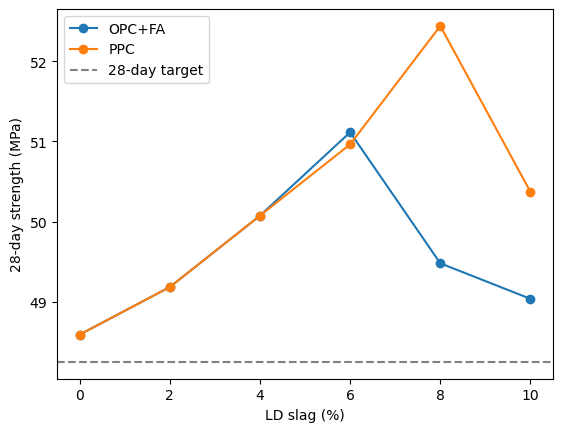

In [20]:
avg28 = df[df.age_days == 28].groupby(["binder", "ld_slag_pct"]).strength_mpa.mean().reset_index()
for binder in ["OPC+FA", "PPC"]:
    d = avg28[avg28.binder == binder]
    plt.plot(d.ld_slag_pct, d.strength_mpa, marker="o", label=binder)
plt.axhline(48.25, ls="--", color="grey", label="28-day target")
plt.xlabel("LD slag (%)"); plt.ylabel("28-day strength (MPa)"); plt.legend(); plt.show()

In [21]:
X = pd.DataFrame({
    "fly_ash": (df.binder == "OPC+FA").astype(float),   # 1 if OPC + fly ash, else 0
    "ppc": (df.binder == "PPC").astype(float),          # 1 if PPC, else 0
    "ld_slag_pct": df.ld_slag_pct.astype(float),
    "log_age": np.log(df.age_days),                     # strength grows roughly with log(age)
})
y = df.strength_mpa
groups = df.mix          # used so each test mix is completely unseen during training
X.head()

,fly_ash,ppc,ld_slag_pct,log_age
0,0.0,0.0,0.0,1.945910
1,0.0,0.0,0.0,1.945910
2,0.0,0.0,0.0,1.945910
3,0.0,0.0,0.0,3.332205
4,0.0,0.0,0.0,3.332205


In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    "Gaussian Process": make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(ConstantKernel() * RBF([1, 1, 1, 1]) + WhiteKernel(),
                                 normalize_y=True, random_state=0)),
}

# Leave-one-mix-out: train on 12 mixes, test on the 13th, repeat for every mix
results = []
for name, model in models.items():
    pred = cross_val_predict(model, X, y, groups=groups, cv=LeaveOneGroupOut())
    results.append({"Model": name,
                    "R2": r2_score(y, pred),
                    "RMSE": np.sqrt(mean_squared_error(y, pred)),
                    "MAE": mean_absolute_error(y, pred)})

results = pd.DataFrame(results).sort_values("RMSE").round(3)
results

,Model,R2,RMSE,MAE
2,XGBoost,0.989,0.969,0.687
3,Gaussian Process,0.989,0.980,0.696
1,Random Forest,0.985,1.128,0.805
0,Linear Regression,0.934,2.379,1.954


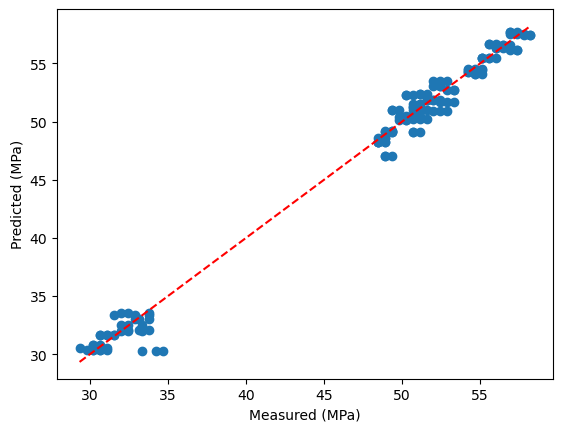

In [23]:
model = models["Gaussian Process"]
model.fit(X, y)

pred = cross_val_predict(model, X, y, groups=groups, cv=LeaveOneGroupOut())
plt.scatter(y, pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Measured (MPa)"); plt.ylabel("Predicted (MPa)"); plt.show()

In [24]:
for binder in ["OPC+FA", "PPC"]:
    slag = np.arange(0, 10.1, 0.5)                  # try 0 %, 0.5 %, ... 10 %
    new = pd.DataFrame({
        "fly_ash": float(binder == "OPC+FA"),
        "ppc": float(binder == "PPC"),
        "ld_slag_pct": slag,
        "log_age": np.log(28),
    })
    strength = model.predict(new)
    best = strength.argmax()
    print(f"{binder}: best LD slag = {slag[best]} %  ->  {strength[best]:.2f} MPa at 28 days")

OPC+FA: best LD slag = 6.5 %  ->  50.64 MPa at 28 days
PPC: best LD slag = 7.5 %  ->  51.58 MPa at 28 days


In [25]:
joblib.dump({
    "model": model,
    "model_name": "Gaussian Process Regressor",
    "training_ranges": {"ld_slag_pct": (0.0, 10.0), "age_days": (7, 90)},
    "targets": {"7": 32.33, "28": 48.25},
    "cv_scores": results.set_index("Model").to_dict(orient="index"),
    "measured_means": df.groupby(["mix", "binder", "ld_slag_pct", "age_days"])
                        .strength_mpa.mean().reset_index().to_dict(orient="records"),
}, "ld_slag_strength_model.pkl")
print("Model saved")

Model saved


In [26]:
import sklearn; print(sklearn.__version__)

1.7.2
